In [1]:
import pandas as pd
import numpy as np
import ast

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv("dataset.csv")

print(df.shape)
df.head()

(298450, 24)


,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,...,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,NaN,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,NaN,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,...,82.0,Bellandur,False,No Junction,NaN,NaN,NaN,NaN,NaN,NaN
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,NaN,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,NaN,"[""NO PARKING""]",[113],2023-11-16 06:47:46+00,...,26.0,Byatarayanapura,True,No Junction,NaN,NaN,FKN00GL0003,SCOOTER,approved,2023-11-18 23:35:12.428+00
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,NaN,"[""NO PARKING""]",[113],2023-11-22 04:56:46+00,...,3.0,Upparpet,True,BTP044 - Sagar Theatre Junction,NaN,NaN,FKN00GL0004,TANKER,approved,2023-11-30 03:11:32.796+00


In [3]:
df["created_datetime"] = pd.to_datetime(
    df["created_datetime"],
    format="mixed",
    utc=True
)

df["date"] = df["created_datetime"].dt.date
df["hour"] = df["created_datetime"].dt.hour
df["day_of_week"] = df["created_datetime"].dt.day_name()

In [4]:
vehicle_weights = {
    "SCOOTER": 1,
    "MOTOR CYCLE": 1,
    "MOPED": 1,

    "CAR": 2,
    "JEEP": 2,
    "PASSENGER AUTO": 2,

    "MAXI-CAB": 3,
    "VAN": 3,

    "GOODS AUTO": 4,

    "LGV": 5,
    "TEMPO": 5,

    "PRIVATE BUS": 8,
    "BUS (BMTC/KSRTC)": 8,
    "SCHOOL VEHICLE": 8,
    "TOURIST BUS": 8,
    "FACTORY BUS": 8,

    "MINI LORRY": 7,

    "LORRY/GOODS VEHICLE": 10,
    "HGV": 10,
    "TANKER": 10,

    "TRACTOR": 6
}

df["vehicle_weight"] = (
    df["vehicle_type"]
    .map(vehicle_weights)
    .fillna(2)
)

In [5]:
severity_map = {
    "PARKING IN A MAIN ROAD": 5,
    "DOUBLE PARKING": 5,

    "PARKING ON FOOTPATH": 4,
    "PARKING NEAR ROAD CROSSING": 4,
    "PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS": 4,
    "PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC": 4,

    "NO PARKING": 3,

    "WRONG PARKING": 2
}

In [6]:
def get_severity(v):
    try:
        violations = ast.literal_eval(v)

        score = sum(
            severity_map.get(x, 1)
            for x in violations
        )

        return score

    except:
        return 1


df["severity_score"] = df["violation_type"].apply(get_severity)

In [7]:
repeat_counts = (
    df.groupby("vehicle_number")
      .size()
      .rename("vehicle_repeat_count")
)

df = df.merge(
    repeat_counts,
    left_on="vehicle_number",
    right_index=True,
    how="left"
)

In [8]:
coords = df[["latitude", "longitude"]].values

kms_per_radian = 6371.0088

epsilon = 0.3 / kms_per_radian

dbscan = DBSCAN(
    eps=epsilon,
    min_samples=50,
    algorithm="ball_tree",
    metric="haversine"
)

df["cluster"] = dbscan.fit_predict(
    np.radians(coords)
)

In [9]:
hotspots = df[df["cluster"] != -1].copy()

print(
    "Hotspots:",
    hotspots["cluster"].nunique()
)

Hotspots: 129


In [10]:
def criticality(junction):

    if pd.isna(junction):
        return 1.0

    junction = str(junction).lower()

    if "metro" in junction:
        return 1.5

    if "market" in junction:
        return 1.5

    if "hospital" in junction:
        return 1.4

    if "bus stop" in junction:
        return 1.4

    if "circle" in junction:
        return 1.2

    if "junction" in junction:
        return 1.2

    return 1.0


hotspots["road_criticality"] = (
    hotspots["junction_name"]
    .apply(criticality)
)

In [11]:
cluster_summary = (
    hotspots.groupby("cluster")
    .agg(
        violations=("id", "count"),

        center_lat=("latitude", "mean"),
        center_lon=("longitude", "mean"),

        avg_vehicle_weight=("vehicle_weight", "mean"),

        avg_severity=("severity_score", "mean"),

        avg_repeat=("vehicle_repeat_count", "mean"),

        avg_criticality=("road_criticality", "mean")
    )
)

In [12]:
compactness = []

for cluster_id in cluster_summary.index:

    subset = hotspots[
        hotspots["cluster"] == cluster_id
    ]

    lat_std = subset["latitude"].std()
    lon_std = subset["longitude"].std()

    c = np.sqrt(
        lat_std**2 +
        lon_std**2
    )

    compactness.append(c)

cluster_summary["compactness"] = compactness

In [13]:
cluster_summary["density"] = (
    cluster_summary["violations"] /
    cluster_summary["compactness"]
)

In [14]:
scaler = MinMaxScaler()

cols = [
    "density",
    "avg_vehicle_weight",
    "avg_severity",
    "avg_repeat",
    "avg_criticality"
]

cluster_summary[
    [c + "_norm" for c in cols]
] = scaler.fit_transform(
    cluster_summary[cols]
)

In [15]:
cluster_summary["PCRI"] = (
      0.35 * cluster_summary["density_norm"]
    + 0.20 * cluster_summary["avg_severity_norm"]
    + 0.15 * cluster_summary["avg_vehicle_weight_norm"]
    + 0.15 * cluster_summary["avg_repeat_norm"]
    + 0.15 * cluster_summary["avg_criticality_norm"]
)

cluster_summary["PCRI"] *= 100

In [16]:
cluster_summary = (
    cluster_summary
    .sort_values(
        "PCRI",
        ascending=False
    )
)

cluster_summary.head(20)

cluster_summary.to_csv(
    "cluster_summary.csv",
    index=False
)

In [18]:
def classify(row):

    if row["avg_repeat_norm"] > 0.7:
        return "Demand Overflow"

    if row["avg_vehicle_weight_norm"] > 0.7:
        return "Heavy Vehicle Obstruction"

    if row["avg_severity_norm"] > 0.7:
        return "High Risk Parking Behavior"

    return "General Illegal Parking"


cluster_summary["root_cause"] = (
    cluster_summary.apply(
        classify,
        axis=1
    )
)

In [19]:
recommendations = {
    "Demand Overflow":
        "Create dedicated parking capacity",

    "Heavy Vehicle Obstruction":
        "Restrict heavy vehicle parking",

    "High Risk Parking Behavior":
        "Deploy focused enforcement",

    "General Illegal Parking":
        "Routine monitoring"
}

cluster_summary["recommendation"] = (
    cluster_summary["root_cause"]
    .map(recommendations)
)

In [20]:
final_hotspots = cluster_summary[
    [
        "PCRI",
        "violations",
        "center_lat",
        "center_lon",
        "root_cause",
        "recommendation"
    ]
]

final_hotspots.head(20)

,PCRI,violations,center_lat,center_lon,root_cause,recommendation
cluster,,,,,,
2,50.352650,188420,12.978490,77.578576,General Illegal Parking,Routine monitoring
109,42.752915,69,12.927342,77.597349,High Risk Parking Behavior,Deploy focused enforcement
27,35.452832,6226,13.070997,77.588444,General Illegal Parking,Routine monitoring
72,30.325881,250,13.050495,77.525531,Demand Overflow,Create dedicated parking capacity
42,28.125552,569,12.978932,77.695302,General Illegal Parking,Routine monitoring
108,28.120584,104,12.956651,77.745392,Heavy Vehicle Obstruction,Restrict heavy vehicle parking
6,27.681664,25440,12.941689,77.695445,General Illegal Parking,Routine monitoring
59,27.342819,1264,12.971788,77.658011,General Illegal Parking,Routine monitoring
11,27.179964,5086,13.185398,77.680504,General Illegal Parking,Routine monitoring


In [21]:
cluster_summary[[
    "violations",
    "compactness",
    "density"
]].describe()

,violations,compactness,density
count,129.000000,129.000000,1.290000e+02
mean,2277.643411,0.002548,3.009707e+05
std,16731.474292,0.003877,6.909842e+05
min,37.000000,0.000167,2.666200e+04
25%,73.000000,0.001145,5.626529e+04
50%,127.000000,0.001472,9.734067e+04
75%,341.000000,0.002288,2.434892e+05
max,188420.000000,0.030005,6.279610e+06


In [22]:
print("Clusters:", cluster_summary.shape[0])

print("Largest cluster:",
      cluster_summary["violations"].max())

print("Median cluster:",
      cluster_summary["violations"].median())

Clusters: 129
Largest cluster: 188420
Median cluster: 127.0


In [23]:
cluster_summary[
    ["PCRI","violations"]
].corr()

,PCRI,violations
PCRI,1.000000,0.496944
violations,0.496944,1.000000


In [24]:
top = cluster_summary.nlargest(10,"PCRI")
bottom = cluster_summary.nsmallest(10,"PCRI")

print(top[[
    "PCRI",
    "violations",
    "avg_severity",
    "avg_vehicle_weight",
    "avg_repeat"
]])

print(bottom[[
    "PCRI",
    "violations",
    "avg_severity",
    "avg_vehicle_weight",
    "avg_repeat"
]])

              PCRI  violations  avg_severity  avg_vehicle_weight  avg_repeat
cluster                                                                     
2        50.352650      188420      2.753206            1.740532    2.260657
109      42.752915          69     12.391304            2.768116    1.333333
27       35.452832        6226      2.522004            1.211532    3.446675
72       30.325881         250      2.532000            1.000000    6.648000
42       28.125552         569      7.558875            2.541301    1.695958
108      28.120584         104      4.692308            4.942308    1.144231
6        27.681664       25440      4.169536            2.038483    2.837814
59       27.342819        1264      3.726266            1.424842    2.754747
11       27.179964        5086      3.668502            2.303775    1.559772
22       26.491779        1718      4.360885            3.736321    2.091967
              PCRI  violations  avg_severity  avg_vehicle_weight  avg_repeat

In [25]:
cluster_summary["repeat_rate"] = (
    cluster_summary["avg_repeat"] - 1
)

cluster_summary[[
    "PCRI",
    "repeat_rate"
]].corr()

,PCRI,repeat_rate
PCRI,1.000000,0.437519
repeat_rate,0.437519,1.000000


In [26]:
cluster_summary[[
    "PCRI",
    "avg_severity"
]].corr()

,PCRI,avg_severity
PCRI,1.000000,0.483744
avg_severity,0.483744,1.000000


In [27]:
print(cluster_summary.shape)

print(
    cluster_summary["violations"].describe()
)

print(
    cluster_summary[[
        "PCRI",
        "violations"
    ]].corr()
)

(129, 18)
count       129.000000
mean       2277.643411
std       16731.474292
min          37.000000
25%          73.000000
50%         127.000000
75%         341.000000
max      188420.000000
Name: violations, dtype: float64
                PCRI  violations
PCRI        1.000000    0.496944
violations  0.496944    1.000000


In [28]:
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd

coords = df[["latitude", "longitude"]].values

kms_per_radian = 6371.0088

for meters in [100, 150, 200]:

    eps = (meters / 1000) / kms_per_radian

    db = DBSCAN(
        eps=eps,
        min_samples=50,
        metric="haversine",
        algorithm="ball_tree"
    )

    labels = db.fit_predict(
        np.radians(coords)
    )

    valid = pd.Series(labels)

    clusters = len(set(labels)) - (1 if -1 in labels else 0)

    largest = (
        valid[valid != -1]
        .value_counts()
        .max()
    )

    median = (
        valid[valid != -1]
        .value_counts()
        .median()
    )

    print(
        f"{meters}m | "
        f"clusters={clusters} | "
        f"largest={largest} | "
        f"median={median}"
    )

100m | clusters=300 | largest=61219 | median=146.5
150m | clusters=242 | largest=76208 | median=176.0
200m | clusters=184 | largest=117500 | median=178.0


In [29]:
pip install h3


   ---------------------------------------- 0.0/806.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/806.1 kB ? eta -:--:--
    --------------------------------------- 10.2/806.1 kB ? eta -:--:--
    --------------------------------------- 10.2/806.1 kB ? eta -:--:--
    --------------------------------------- 10.2/806.1 kB ? eta -:--:--
   - ------------------------------------- 30.7/806.1 kB 187.9 kB/s eta 0:00:05
   -- ------------------------------------ 61.4/806.1 kB 299.4 kB/s eta 0:00:03
   ---- --------------------------------- 102.4/806.1 kB 454.0 kB/s eta 0:00:02
   ------ ------------------------------- 143.4/806.1 kB 502.3 kB/s eta 0:00:02
   -------- ----------------------------- 184.3/806.1 kB 588.1 kB/s eta 0:00:02
   ------------ ------------------------- 256.0/806.1 kB 749.3 kB/s eta 0:00:01
   ------------- ------------------------ 286.7/806.1 kB 708.9 kB/s eta 0:00:01
   ----------------- -------------------- 368.6/806.1 kB 820.1 kB/s eta 0:00:01
 

In [30]:
from h3 import latlng_to_cell
import pandas as pd

# Resolution 9 ≈ 100-150m cells
RESOLUTION = 9

df["h3_cell"] = df.apply(
    lambda row: latlng_to_cell(
        row["latitude"],
        row["longitude"],
        RESOLUTION
    ),
    axis=1
)

cell_stats = (
    df.groupby("h3_cell")
      .agg(
          violations=("id","count"),
          center_lat=("latitude","mean"),
          center_lon=("longitude","mean"),
          avg_severity=("severity_score","mean"),
          avg_vehicle_weight=("vehicle_weight","mean"),
          avg_repeat=("vehicle_repeat_count","mean")
      )
)

cell_stats.sort_values(
    "violations",
    ascending=False
).head(20)

,violations,center_lat,center_lon,avg_severity,avg_vehicle_weight,avg_repeat
h3_cell,,,,,,
8960145b553ffff,12123,12.976631,77.576306,2.614204,1.536006,2.711870
8960145b59bffff,8585,12.964325,77.576638,2.308911,1.621433,1.895282
8960145b427ffff,7369,12.977510,77.578937,2.656534,2.036097,2.711630
89618920923ffff,6749,12.933558,77.690979,4.540376,1.172915,6.186546
8961892e9abffff,6667,12.981677,77.607850,2.597570,1.389831,3.829009
8960145b5cbffff,5992,12.973735,77.578668,2.811081,1.567757,2.917557
8961892e917ffff,4874,12.982273,77.610640,2.579606,1.603406,2.950964
8960145b3a7ffff,4293,12.999720,77.549722,2.374330,1.368041,2.614489
8961892e9bbffff,4257,12.980889,77.610168,2.932112,1.998356,3.128494


In [32]:
top20 = cell_stats.sort_values(
    "violations",
    ascending=False
).head(20)

top20[[
    "center_lat",
    "center_lon",
    "violations"
]]

,center_lat,center_lon,violations
h3_cell,,,
8960145b553ffff,12.976631,77.576306,12123
8960145b59bffff,12.964325,77.576638,8585
8960145b427ffff,12.977510,77.578937,7369
89618920923ffff,12.933558,77.690979,6749
8961892e9abffff,12.981677,77.607850,6667
8960145b5cbffff,12.973735,77.578668,5992
8961892e917ffff,12.982273,77.610640,4874
8960145b3a7ffff,12.999720,77.549722,4293
8961892e9bbffff,12.980889,77.610168,4257


In [33]:
import ast

BLOCKING_VIOLATIONS = {
    "PARKING IN A MAIN ROAD",
    "DOUBLE PARKING",
    "PARKING ON FOOTPATH",
    "PARKING NEAR ROAD CROSSING",
    "PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS",
    "PARKING OPPOSITE TO ANOTHER PARKED VEHICLE",
    "PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC"
}

def is_blocking(violation_string):
    try:
        violations = ast.literal_eval(violation_string)

        for v in violations:
            if v in BLOCKING_VIOLATIONS:
                return 1

        return 0

    except:
        return 0

df["blocking_violation"] = (
    df["violation_type"]
    .apply(is_blocking)
)

print(
    "Blocking Violation Rate:",
    round(
        df["blocking_violation"].mean() * 100,
        2
    ),
    "%"
)

Blocking Violation Rate: 10.31 %


In [34]:
df["h3_cell"]

0         89618925c03ffff
1         8961892729bffff
2         89618925c03ffff
3         8960145a323ffff
4         8960145b423ffff
               ...       
298445    8961892c8d7ffff
298446    8960145b553ffff
298447    8960145b59bffff
298448    89618927213ffff
298449    89618920b03ffff
Name: h3_cell, Length: 298450, dtype: object

In [35]:
cell_summary = (
    df.groupby("h3_cell")
      .agg(
          violations=("id", "count"),

          center_lat=("latitude", "mean"),
          center_lon=("longitude", "mean"),

          avg_severity=("severity_score", "mean"),

          avg_vehicle_weight=("vehicle_weight", "mean"),

          avg_repeat=("vehicle_repeat_count", "mean"),

          blocking_ratio=("blocking_violation", "mean")
      )
)

cell_summary.head()

,violations,center_lat,center_lon,avg_severity,avg_vehicle_weight,avg_repeat,blocking_ratio
h3_cell,,,,,,,
8960144a2cbffff,1,13.071527,77.442553,2.000000,10.000000,1.000000,0.000000
8960144a2dbffff,4,13.070772,77.443840,2.000000,8.000000,1.000000,0.000000
8960144a64bffff,3,13.065641,77.453351,6.666667,3.000000,1.333333,0.666667
8960144b4dbffff,19,13.085203,77.486469,2.052632,1.000000,1.157895,0.000000
8960144b5a3ffff,14,13.068092,77.448802,2.000000,6.142857,1.000000,0.000000


In [36]:
def road_criticality(junction):

    if pd.isna(junction):
        return 1.0

    junction = str(junction).lower()

    if "metro" in junction:
        return 1.5

    if "market" in junction:
        return 1.5

    if "hospital" in junction:
        return 1.4

    if "bus stop" in junction:
        return 1.4

    if "circle" in junction:
        return 1.2

    if "junction" in junction:
        return 1.2

    return 1.0

In [37]:
cell_junction = (
    df.groupby("h3_cell")["junction_name"]
      .agg(
          lambda x:
          x.value_counts().index[0]
          if len(x.value_counts()) > 0
          else None
      )
)

cell_summary["dominant_junction"] = cell_junction

In [38]:
cell_summary["road_criticality"] = (
    cell_summary["dominant_junction"]
    .apply(road_criticality)
)

In [39]:
from sklearn.preprocessing import MinMaxScaler

features = [
    "violations",
    "avg_severity",
    "avg_vehicle_weight",
    "avg_repeat",
    "blocking_ratio",
    "road_criticality"
]

scaler = MinMaxScaler()

cell_summary[
    [f + "_norm" for f in features]
] = scaler.fit_transform(
    cell_summary[features]
)

In [40]:
cell_summary["PCRI"] = (
      0.25 * cell_summary["violations_norm"]
    + 0.20 * cell_summary["blocking_ratio_norm"]
    + 0.15 * cell_summary["avg_severity_norm"]
    + 0.15 * cell_summary["avg_vehicle_weight_norm"]
    + 0.15 * cell_summary["avg_repeat_norm"]
    + 0.10 * cell_summary["road_criticality_norm"]
)

cell_summary["PCRI"] *= 100

In [41]:
def classify(row):

    if row["avg_repeat"] > 3:
        return "Demand Overflow"

    if row["avg_vehicle_weight"] > 3:
        return "Heavy Vehicle Obstruction"

    if row["blocking_ratio"] > 0.4:
        return "Road Capacity Reduction"

    return "General Illegal Parking"

cell_summary["root_cause"] = (
    cell_summary.apply(
        classify,
        axis=1
    )
)

In [42]:
recommendation_map = {
    "Demand Overflow":
        "Create dedicated parking capacity",

    "Heavy Vehicle Obstruction":
        "Restrict heavy vehicle parking",

    "Road Capacity Reduction":
        "Increase enforcement and towing",

    "General Illegal Parking":
        "Routine monitoring"
}

cell_summary["recommendation"] = (
    cell_summary["root_cause"]
    .map(recommendation_map)
)

In [43]:
top25 = (
    cell_summary
    .sort_values(
        "PCRI",
        ascending=False
    )
    .head(25)
)

top25[
    [
        "PCRI",
        "violations",
        "blocking_ratio",
        "avg_repeat",
        "avg_vehicle_weight",
        "dominant_junction",
        "root_cause",
        "recommendation"
    ]
]

,PCRI,violations,blocking_ratio,avg_repeat,avg_vehicle_weight,dominant_junction,root_cause,recommendation
h3_cell,,,,,,,,
89618925d47ffff,48.757876,2,1.0,1.000,10.00,"BTP127 - Sagar Hospital, Jayanagar",Heavy Vehicle Obstruction,Restrict heavy vehicle parking
8961892f66fffff,47.372093,1,1.0,1.000,10.00,No Junction,Heavy Vehicle Obstruction,Restrict heavy vehicle parking
896014591cfffff,47.372093,1,1.0,1.000,10.00,No Junction,Heavy Vehicle Obstruction,Restrict heavy vehicle parking
8960145a01bffff,47.372093,1,1.0,1.000,10.00,No Junction,Heavy Vehicle Obstruction,Restrict heavy vehicle parking
896016913d3ffff,47.372093,1,1.0,1.000,10.00,No Junction,Heavy Vehicle Obstruction,Restrict heavy vehicle parking
8960145910bffff,47.372093,1,1.0,1.000,10.00,No Junction,Heavy Vehicle Obstruction,Restrict heavy vehicle parking
8961892e4c3ffff,46.960271,1,1.0,2.000,8.00,No Junction,Heavy Vehicle Obstruction,Restrict heavy vehicle parking
8961892f67bffff,45.283194,3,1.0,1.000,10.00,No Junction,Heavy Vehicle Obstruction,Restrict heavy vehicle parking
8961892f61bffff,45.281132,2,1.0,1.000,10.00,No Junction,Heavy Vehicle Obstruction,Restrict heavy vehicle parking


In [44]:
top25[
    [
        "PCRI",
        "violations",
        "dominant_junction",
        "root_cause"
    ]
]

,PCRI,violations,dominant_junction,root_cause
h3_cell,,,,
89618925d47ffff,48.757876,2,"BTP127 - Sagar Hospital, Jayanagar",Heavy Vehicle Obstruction
8961892f66fffff,47.372093,1,No Junction,Heavy Vehicle Obstruction
896014591cfffff,47.372093,1,No Junction,Heavy Vehicle Obstruction
8960145a01bffff,47.372093,1,No Junction,Heavy Vehicle Obstruction
896016913d3ffff,47.372093,1,No Junction,Heavy Vehicle Obstruction
8960145910bffff,47.372093,1,No Junction,Heavy Vehicle Obstruction
8961892e4c3ffff,46.960271,1,No Junction,Heavy Vehicle Obstruction
8961892f67bffff,45.283194,3,No Junction,Heavy Vehicle Obstruction
8961892f61bffff,45.281132,2,No Junction,Heavy Vehicle Obstruction


In [46]:
print(cell_summary["violations"].describe())

count     2534.000000
mean       117.778216
std        506.592967
min          1.000000
25%          3.000000
50%         11.000000
75%         54.000000
max      12123.000000
Name: violations, dtype: float64


In [47]:
cell_summary = cell_summary[
    cell_summary["violations"] >= 50
].copy()

In [48]:
cell_summary["log_violations"] = np.log1p(
    cell_summary["violations"]
)

In [49]:
features = [
    "log_violations",
    "blocking_ratio",
    "avg_severity",
    "avg_vehicle_weight",
    "avg_repeat",
    "road_criticality"
]

In [50]:
scaler = MinMaxScaler()

cell_summary[
    [f + "_norm" for f in features]
] = scaler.fit_transform(
    cell_summary[features]
)

In [51]:
cell_summary["PCRI"] = (
      0.40 * cell_summary["log_violations_norm"]
    + 0.20 * cell_summary["blocking_ratio_norm"]
    + 0.15 * cell_summary["avg_severity_norm"]
    + 0.10 * cell_summary["avg_vehicle_weight_norm"]
    + 0.10 * cell_summary["avg_repeat_norm"]
    + 0.05 * cell_summary["road_criticality_norm"]
)

cell_summary["PCRI"] *= 100

In [52]:
top25 = (
    cell_summary
    .sort_values(
        "PCRI",
        ascending=False
    )
    .head(25)
)

top25[
    [
        "PCRI",
        "violations",
        "dominant_junction",
        "avg_repeat",
        "blocking_ratio"
    ]
]

,PCRI,violations,dominant_junction,avg_repeat,blocking_ratio
h3_cell,,,,,
89618920923ffff,56.524781,6749,No Junction,6.186546,0.304934
89618920963ffff,54.169942,1509,No Junction,1.516899,0.898608
8961892e16bffff,50.703234,1305,No Junction,1.805364,0.737165
89618920babffff,50.086178,976,No Junction,1.839139,0.701844
896189219cfffff,49.122609,553,No Junction,1.708861,0.992767
8961892e3b7ffff,49.047194,694,No Junction,1.737752,0.773775
8960145b553ffff,46.963258,12123,BTP040 - Elite Junction,2.711870,0.014765
8960145b59bffff,45.979610,8585,BTP082 - KR Market Junction,1.895282,0.026674
8961892e9abffff,44.774141,6667,BTP051 - Safina Plaza Junction,3.829009,0.038098


In [53]:
suspicious = [
    "89618920923ffff",
    "89618920963ffff",
    "8961892e16bffff",
    "89618920babffff",
    "896189219cfffff"
]

df[
    df["h3_cell"].isin(suspicious)
][[
    "latitude",
    "longitude",
    "location",
    "junction_name",
    "violation_type"
]].head(20)

,latitude,longitude,location,junction_name,violation_type
24,12.934068,77.689769,"Outer Ring Road, Prestige Silver Crest, Kadubi...",No Junction,"[""WRONG PARKING"",""NO PARKING"",""PARKING NEAR BU..."
27,12.934068,77.689769,"Outer Ring Road, Prestige Silver Crest, Kadubi...",No Junction,"[""NO PARKING"",""WRONG PARKING"",""PARKING NEAR BU..."
41,12.939710,77.695477,"Kadubeesanahalli Underpass, Kadubisanahalli Ju...",No Junction,"[""PARKING IN A MAIN ROAD"",""WRONG PARKING""]"
43,12.939735,77.695530,"Kadubeesanahalli Underpass, Kadubisanahalli Ju...",No Junction,"[""PARKING IN A MAIN ROAD"",""WRONG PARKING""]"
45,12.939747,77.695501,"Kadubeesanahalli Underpass, Kadubisanahalli Ju...",No Junction,"[""PARKING IN A MAIN ROAD"",""WRONG PARKING""]"
46,12.939734,77.695485,"Kadubeesanahalli Underpass, Kadubisanahalli Ju...",No Junction,"[""PARKING IN A MAIN ROAD"",""WRONG PARKING""]"
65,12.939683,77.695504,"Kadubeesanahalli Underpass, Kadubisanahalli Ju...",No Junction,"[""PARKING IN A MAIN ROAD"",""WRONG PARKING""]"
66,12.939790,77.695498,"Outer Ring Road, Kadubisanahalli Junction, Kad...",No Junction,"[""PARKING IN A MAIN ROAD"",""WRONG PARKING""]"
72,12.939754,77.695622,"Kadubeesanahalli Underpass, Kadubisanahalli Ju...",No Junction,"[""PARKING IN A MAIN ROAD"",""WRONG PARKING""]"
75,12.939753,77.695676,"Kadubeesanahalli Underpass, Indiqube Alpha, Re...",No Junction,"[""PARKING IN A MAIN ROAD"",""NO PARKING""]"


In [54]:
for cell in suspicious:

    subset = df[df["h3_cell"] == cell]

    print("\n\nCELL:", cell)

    print(
        subset["location"]
        .value_counts()
        .head(10)
    )



CELL: 89618920923ffff
location
New Horizon College Road, New Horizon College of Engineering, Kadubisanahalli, Bengaluru, Karnataka. Pin-560103 (India)                                                                                       3782
New Horizon College Road, Embassy Tech Village, Devara Beesana Halli, Bengaluru, Karnataka. Pin-560103 (India)                                                                                                2333
Outer Ring Road, Prestige Silver Crest, Kadubisanahalli, Bengaluru, Karnataka. Pin-560103 (India)                                                                                                              252
Outer Ring Road, Embassy Tech Village, Devara Beesana Halli, Bengaluru, Karnataka. Pin-560103 (India)                                                                                                           60
Outer Ring Road, Rajiv Nagar, Kadubisanahalli, Bengaluru, Karnataka. Pin-560103 (India)                                    

In [55]:
def hotspot_name(group):
    return group["location"].value_counts().index[0]

In [58]:
cell_summary["hotspot_name"] = (
    df.groupby("h3_cell")["location"]
      .agg(
          lambda x:
          x.dropna().value_counts().idxmax()
          if len(x.dropna()) > 0
          else "Unknown Location"
      )
)

cell_summary["dominant_junction"] = (
    df.groupby("h3_cell")["junction_name"]
      .agg(
          lambda x:
          x.dropna().value_counts().idxmax()
          if len(x.dropna()) > 0
          else "No Junction"
      )
)

In [59]:
cell_names = (
    df.groupby("h3_cell")["location"]
      .agg(
          lambda x:
          x.dropna().value_counts().index[0]
          if len(x.dropna()) > 0
          else "Unknown Location"
      )
)

cell_summary["hotspot_name"] = cell_names

In [60]:
prototype_df = (
    cell_summary
    .sort_values("PCRI", ascending=False)
    .reset_index()
)

prototype_df = prototype_df[
    [
        "hotspot_name",
        "center_lat",
        "center_lon",
        "PCRI",
        "violations",
        "blocking_ratio",
        "avg_repeat",
        "dominant_junction",
        "root_cause",
        "recommendation"
    ]
]

In [61]:
prototype_df = (
    cell_summary
    .sort_values("PCRI", ascending=False)
    .reset_index()
)

prototype_df[[
    "hotspot_name",
    "dominant_junction",
    "PCRI",
    "violations",
    "blocking_ratio",
    "avg_repeat"
]].head(20)

,hotspot_name,dominant_junction,PCRI,violations,blocking_ratio,avg_repeat
0,"New Horizon College Road, New Horizon College ...",No Junction,56.524781,6749,0.304934,6.186546
1,"Kadubeesanahalli Underpass, Kadubisanahalli Ju...",No Junction,54.169942,1509,0.898608,1.516899
2,"MBT Road, Royal Heritage, Pai Layout, Mahadeva...",No Junction,50.703234,1305,0.737165,1.805364
3,"Outer Ring Road, Soulspace Paradigm, Marathaha...",No Junction,50.086178,976,0.701844,1.839139
4,"Whitefield Road, Sadaramangala Industrial Area...",No Junction,49.122609,553,0.992767,1.708861
5,"MBT Road, Tin Factory Junction, Dooravani Naga...",No Junction,49.047194,694,0.773775,1.737752
6,"5th Main Road, Kempe Gowda Circle, Gandhi Naga...",BTP040 - Elite Junction,46.963258,12123,0.014765,2.711870
7,"Mysore Road, Sri Krishna Rajendra Market, Chic...",BTP082 - KR Market Junction,45.979610,8585,0.026674,1.895282
8,"Dispensary Road, Tasker Town, Shivaji Nagar, B...",BTP051 - Safina Plaza Junction,44.774141,6667,0.038098,3.829009
9,"3rd Main Road, Sri Kanakadasa Circle, Gandhi N...",BTP044 - Sagar Theatre Junction,44.182313,7369,0.013435,2.711630


In [62]:
prototype_df[
    [
        "PCRI",
        "violations",
        "blocking_ratio",
        "avg_repeat"
    ]
].corr()

,PCRI,violations,blocking_ratio,avg_repeat
PCRI,1.000000,0.563861,0.516807,0.350863
violations,0.563861,1.000000,-0.085028,0.317041
blocking_ratio,0.516807,-0.085028,1.000000,-0.130608
avg_repeat,0.350863,0.317041,-0.130608,1.000000


In [64]:
prototype_df["root_cause"].value_counts()

root_cause
General Illegal Parking      516
Road Capacity Reduction       68
Demand Overflow               39
Heavy Vehicle Obstruction     39
Name: count, dtype: int64

In [65]:
import numpy as np

prototype_df["confidence"] = (
    np.log1p(prototype_df["violations"])
    / np.log1p(prototype_df["violations"].max())
) * 100

In [66]:
prototype_df.to_csv(
    "gridlock_hotspots_final.csv",
    index=False
)

In [67]:
cell_summary.to_csv(
    "gridlock_cell_summary.csv"
)

In [70]:
df["created_datetime"] = pd.to_datetime(
    df["created_datetime"],
    format="mixed",
    utc=True
)

df["date"] = df["created_datetime"].dt.date

daily_hotspots = (
    df.groupby(["h3_cell", "date"])
      .size()
      .reset_index(name="violations")
)

hotspot_days = (
    daily_hotspots.groupby("h3_cell")
    .agg(
        active_days=("date", "nunique"),
        total_violations=("violations", "sum")
    )
    .sort_values(
        "total_violations",
        ascending=False
    )
)

hotspot_days.head(20)

,active_days,total_violations
h3_cell,,
8960145b553ffff,152,12123
8960145b59bffff,152,8585
8960145b427ffff,151,7369
89618920923ffff,108,6749
8961892e9abffff,149,6667
8960145b5cbffff,152,5992
8961892e917ffff,150,4874
8960145b3a7ffff,140,4293
8961892e9bbffff,142,4257


In [69]:
print(
    hotspot_days[
        ["active_days", "total_violations"]
    ].head(10)
)

                 active_days  total_violations
h3_cell                                       
8960145b553ffff          152             12123
8960145b59bffff          152              8585
8960145b427ffff          151              7369
89618920923ffff          108              6749
8961892e9abffff          149              6667
8960145b5cbffff          152              5992
8961892e917ffff          150              4874
8960145b3a7ffff          140              4293
8961892e9bbffff          142              4257
8960145a26bffff          114              3653


In [71]:
top_cell = "8960145b553ffff"

cell_daily = (
    daily_hotspots[
        daily_hotspots["h3_cell"] == top_cell
    ]
    .sort_values("date")
)

print(cell_daily.head())
print(cell_daily.tail())

print("\nDays:", len(cell_daily))
print("Mean:", cell_daily["violations"].mean())
print("Std:", cell_daily["violations"].std())
print("Max:", cell_daily["violations"].max())

               h3_cell        date  violations
15806  8960145b553ffff  2023-11-09           1
15807  8960145b553ffff  2023-11-10          54
15808  8960145b553ffff  2023-11-11          62
15809  8960145b553ffff  2023-11-12          62
15810  8960145b553ffff  2023-11-13          78
               h3_cell        date  violations
15953  8960145b553ffff  2024-04-04          53
15954  8960145b553ffff  2024-04-05          21
15955  8960145b553ffff  2024-04-06         111
15956  8960145b553ffff  2024-04-07          89
15957  8960145b553ffff  2024-04-08          80

Days: 152
Mean: 79.75657894736842
Std: 43.68596493829284
Max: 234


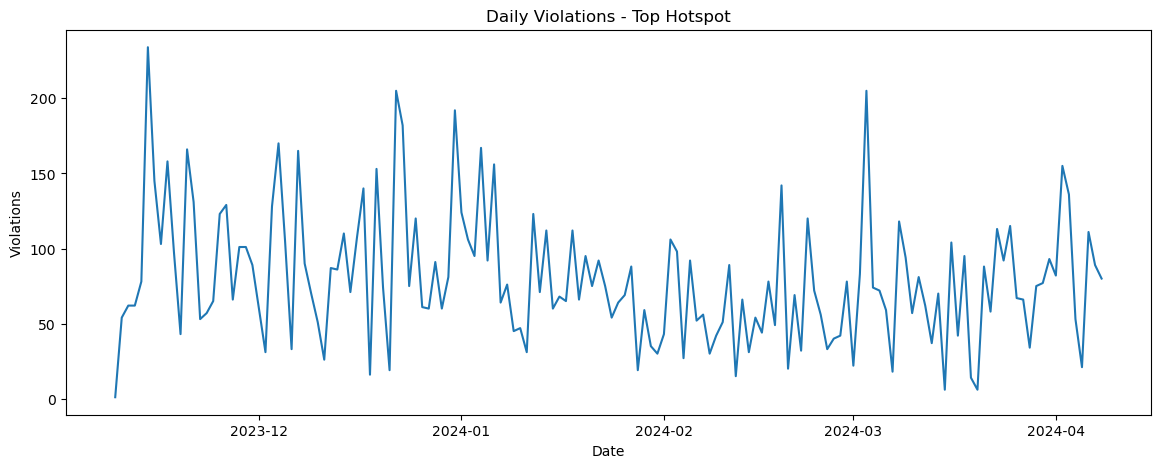

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(
    cell_daily["date"],
    cell_daily["violations"]
)

plt.title("Daily Violations - Top Hotspot")
plt.xlabel("Date")
plt.ylabel("Violations")

plt.show()

In [73]:
top_hotspots = (
    prototype_df
    .sort_values("PCRI", ascending=False)
    .head(20)
)

top_cells = top_hotspots["h3_cell"].tolist()

In [74]:
df["hour"] = df["created_datetime"].dt.hour

hourly_stats = (
    df[df["h3_cell"].isin(top_cells)]
    .groupby(["h3_cell", "hour"])
    .size()
    .reset_index(name="violations")
)

In [75]:
peak_hours = (
    hourly_stats
    .sort_values(
        "violations",
        ascending=False
    )
    .groupby("h3_cell")
    .first()
    .reset_index()
)

peak_hours.head(20)

,h3_cell,hour,violations
0,89601458293ffff,5,46
1,8960145a26bffff,3,543
2,8960145b427ffff,19,1405
3,8960145b553ffff,3,1876
4,8960145b59bffff,19,1558
5,8960145b5cbffff,3,1007
6,89601690193ffff,23,367
7,8961892086bffff,3,76
8,89618920923ffff,22,1101
9,89618920963ffff,3,337


In [76]:
prototype_df = prototype_df.merge(
    peak_hours[["h3_cell", "hour"]],
    on="h3_cell",
    how="left"
)

prototype_df.rename(
    columns={
        "hour": "peak_hour"
    },
    inplace=True
)

In [77]:
prototype_df.head()

,h3_cell,violations,center_lat,center_lon,avg_severity,avg_vehicle_weight,avg_repeat,blocking_ratio,dominant_junction,road_criticality,...,blocking_ratio_norm,road_criticality_norm,PCRI,root_cause,recommendation,log_violations,log_violations_norm,hotspot_name,confidence,peak_hour
0,89618920923ffff,6749,12.933558,77.690979,4.540376,1.172915,6.186546,0.304934,No Junction,1.2,...,0.304934,0.4,56.524781,Demand Overflow,Create dedicated parking capacity,8.817298,0.892957,"New Horizon College Road, New Horizon College ...",93.771689,22.0
1,89618920963ffff,1509,12.939765,77.695531,6.797217,2.426110,1.516899,0.898608,No Junction,1.2,...,0.898608,0.4,54.169942,Road Capacity Reduction,Increase enforcement and towing,7.319865,0.619259,"Kadubeesanahalli Underpass, Kadubisanahalli Ju...",77.846537,3.0
2,8961892e16bffff,1305,12.996058,77.668195,6.678161,2.706513,1.805364,0.737165,No Junction,1.2,...,0.737165,0.4,50.703234,Road Capacity Reduction,Increase enforcement and towing,7.174724,0.592731,"MBT Road, Royal Heritage, Pai Layout, Mahadeva...",76.302971,4.0
3,89618920babffff,976,12.950923,77.699838,6.271516,4.317623,1.839139,0.701844,No Junction,1.2,...,0.701844,0.4,50.086178,Heavy Vehicle Obstruction,Restrict heavy vehicle parking,6.884487,0.539682,"Outer Ring Road, Soulspace Paradigm, Marathaha...",73.216303,22.0
4,896189219cfffff,553,12.987564,77.734748,8.616637,1.048825,1.708861,0.992767,No Junction,1.2,...,0.992767,0.4,49.122609,Road Capacity Reduction,Increase enforcement and towing,6.317165,0.435988,"Whitefield Road, Sadaramangala Industrial Area...",67.182851,6.0


In [78]:
prototype_df.to_csv(
    "gridlock_final_dataset.csv",
    index=False
)

In [87]:
def build_insight(row):
    return (
        f"{row['hotspot_name']} recorded "
        f"{row['violations']} violations with a "
        f"PCRI of {row['PCRI']:.1f}. "
        f"The dominant issue is "
        f"{row['root_cause']}. "
        f"Recommended enforcement around "
        f"{row['peak_hour']}:00."
    )

In [88]:
prototype_df["insight"] = (
    prototype_df.apply(
        build_insight,
        axis=1
    )
)

In [81]:
prototype_df.shape

(662, 25)

In [82]:
print("Total hotspots:", len(prototype_df))

print("\nViolations distribution:")
print(prototype_df["violations"].describe())

Total hotspots: 662

Violations distribution:
count      662.000000
mean       420.158610
std        926.868086
min         50.000000
25%         82.000000
50%        152.500000
75%        364.750000
max      12123.000000
Name: violations, dtype: float64


In [83]:
print(
    prototype_df["violations"]
    .quantile([0.25,0.5,0.75,0.9,0.95,0.99])
)

0.25      82.00
0.50     152.50
0.75     364.75
0.90     879.70
0.95    1424.25
0.99    4519.59
Name: violations, dtype: float64


In [84]:
print(">=100 violations:",
      (prototype_df["violations"] >= 100).sum())

print(">=250 violations:",
      (prototype_df["violations"] >= 250).sum())

print(">=500 violations:",
      (prototype_df["violations"] >= 500).sum())

>=100 violations: 446
>=250 violations: 233
>=500 violations: 125


In [98]:
prototype_df["peak_hour"].isna().sum()

0

In [97]:
print(len(peak_hours))
print(peak_hours["h3_cell"].nunique())

2534
2534


In [99]:
print(len(prototype_df))
print(prototype_df["h3_cell"].nunique())

662
662


In [100]:
print(prototype_df["h3_cell"].dtype)
print(peak_hours["h3_cell"].dtype)

object
object


In [101]:
print(prototype_df["h3_cell"].head())

print("\n")

print(peak_hours["h3_cell"].head())

0    89618920923ffff
1    89618920963ffff
2    8961892e16bffff
3    89618920babffff
4    896189219cfffff
Name: h3_cell, dtype: object


0    8960144a2cbffff
1    8960144a2dbffff
2    8960144a64bffff
3    8960144b4dbffff
4    8960144b5a3ffff
Name: h3_cell, dtype: object


In [95]:
df["hour"] = df["created_datetime"].dt.hour

hourly_stats = (
    df.groupby(["h3_cell", "hour"])
      .size()
      .reset_index(name="violations")
)

peak_hours = (
    hourly_stats
    .sort_values("violations", ascending=False)
    .groupby("h3_cell")
    .first()
    .reset_index()
)

In [96]:
prototype_df = prototype_df.drop(columns=["peak_hour"], errors="ignore")

prototype_df = prototype_df.merge(
    peak_hours[["h3_cell", "hour"]],
    on="h3_cell",
    how="left"
)

prototype_df.rename(
    columns={"hour": "peak_hour"},
    inplace=True
)

In [102]:
def build_insight(row):
    return (
        f"{row['hotspot_name']} has a PCRI of {row['PCRI']:.1f} "
        f"from {row['violations']} violations. "
        f"Primary issue: {row['root_cause']}. "
        f"Recommended enforcement around {int(row['peak_hour'])}:00."
    )

prototype_df["insight"] = prototype_df.apply(build_insight, axis=1)

In [103]:
prototype_df.to_csv(
    "gridlock_final_dataset.csv",
    index=False
)

In [104]:
TOTAL_DAYS = 152

active_days_df = (
    daily_hotspots.groupby("h3_cell")["date"]
    .nunique()
    .reset_index(name="active_days")
)

prototype_df = prototype_df.merge(
    active_days_df,
    on="h3_cell",
    how="left"
)

prototype_df["persistence_pct"] = (
    prototype_df["active_days"] / TOTAL_DAYS * 100
).round(1)

In [105]:
prototype_df[
    ["hotspot_name", "violations", "active_days", "persistence_pct"]
].sort_values("persistence_pct", ascending=False).head(20)

,hotspot_name,violations,active_days,persistence_pct
6,"5th Main Road, Kempe Gowda Circle, Gandhi Naga...",12123,152,100.0
7,"Mysore Road, Sri Krishna Rajendra Market, Chic...",8585,152,100.0
11,"3rd Cross Road, Kempegowda Extension, Chickpet...",5992,152,100.0
13,"MBT Road, Devasandra Junction, KR Puram, Benga...",3332,152,100.0
9,"3rd Main Road, Sri Kanakadasa Circle, Gandhi N...",7369,151,99.3
17,"Kamaraj Road, Sri Nagamma Devi Circle, Sivanch...",4874,150,98.7
31,"Major T Ramachandrappa Road, AT Extension, Gan...",2914,149,98.0
8,"Dispensary Road, Tasker Town, Shivaji Nagar, B...",6667,149,98.0
35,"Vajreshwari Road, R Subanna Circle, Gandhi Nag...",2213,147,96.7
49,"Da Ra Bendre Road, Kirloskar Foundry, Yeshwant...",2163,146,96.1


In [106]:
import ast

def extract_primary_violation(v):
    try:
        vals = ast.literal_eval(v)
        return vals[0]
    except:
        return None

df["primary_violation"] = df["violation_type"].apply(
    extract_primary_violation
)

dominant_violation = (
    df.groupby("h3_cell")["primary_violation"]
      .agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else "UNKNOWN")
      .reset_index(name="dominant_violation")
)

prototype_df = prototype_df.merge(
    dominant_violation,
    on="h3_cell",
    how="left"
)

In [107]:
prototype_df[
    [
        "hotspot_name",
        "dominant_violation",
        "violations",
        "persistence_pct"
    ]
].sort_values(
    "violations",
    ascending=False
).head(20)

,hotspot_name,dominant_violation,violations,persistence_pct
6,"5th Main Road, Kempe Gowda Circle, Gandhi Naga...",NO PARKING,12123,100.0
7,"Mysore Road, Sri Krishna Rajendra Market, Chic...",WRONG PARKING,8585,100.0
9,"3rd Main Road, Sri Kanakadasa Circle, Gandhi N...",NO PARKING,7369,99.3
0,"New Horizon College Road, New Horizon College ...",NO PARKING,6749,71.1
8,"Dispensary Road, Tasker Town, Shivaji Nagar, B...",WRONG PARKING,6667,98.0
11,"3rd Cross Road, Kempegowda Extension, Chickpet...",NO PARKING,5992,100.0
17,"Kamaraj Road, Sri Nagamma Devi Circle, Sivanch...",WRONG PARKING,4874,98.7
26,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",WRONG PARKING,4293,92.1
15,"Dickenson Road, Sri Nagamma Devi Circle, Sivan...",WRONG PARKING,4257,93.4
10,"Chord Road, Manuvana, Vijaya Nagar, Bengaluru,...",WRONG PARKING,3653,75.0


In [108]:
prototype_df["chronicity_score"] = (
    prototype_df["persistence_pct"] *
    np.log1p(prototype_df["violations"])
)

In [109]:
prototype_df[
    [
        "hotspot_name",
        "violations",
        "persistence_pct",
        "chronicity_score"
    ]
].sort_values(
    "chronicity_score",
    ascending=False
).head(20)

,hotspot_name,violations,persistence_pct,chronicity_score
6,"5th Main Road, Kempe Gowda Circle, Gandhi Naga...",12123,100.0,940.294224
7,"Mysore Road, Sri Krishna Rajendra Market, Chic...",8585,100.0,905.788825
9,"3rd Main Road, Sri Kanakadasa Circle, Gandhi N...",7369,99.3,884.283677
11,"3rd Cross Road, Kempegowda Extension, Chickpet...",5992,100.0,869.834740
8,"Dispensary Road, Tasker Town, Shivaji Nagar, B...",6667,98.0,862.897374
17,"Kamaraj Road, Sri Nagamma Devi Circle, Sivanch...",4874,98.7,838.148100
13,"MBT Road, Devasandra Junction, KR Puram, Benga...",3332,100.0,811.162808
31,"Major T Ramachandrappa Road, AT Extension, Gan...",2914,98.0,781.807260
15,"Dickenson Road, Sri Nagamma Devi Circle, Sivan...",4257,93.4,780.502223
26,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",4293,92.1,770.414103


In [110]:
for col in [
    "PCRI",
    "persistence_pct",
    "violations"
]:
    prototype_df[f"{col}_norm"] = (
        prototype_df[col] - prototype_df[col].min()
    ) / (
        prototype_df[col].max() - prototype_df[col].min()
    )

In [111]:
prototype_df["priority_score"] = (
      prototype_df["PCRI_norm"] * 0.5
    + prototype_df["persistence_pct_norm"] * 0.3
    + prototype_df["violations_norm"] * 0.2
) * 100

In [112]:
prototype_df[
    [
        "hotspot_name",
        "priority_score",
        "PCRI",
        "persistence_pct",
        "violations"
    ]
].sort_values(
    "priority_score",
    ascending=False
).head(20)

,hotspot_name,priority_score,PCRI,persistence_pct,violations
6,"5th Main Road, Kempe Gowda Circle, Gandhi Naga...",91.151371,46.963258,100.0,12123
7,"Mysore Road, Sri Krishna Rajendra Market, Chic...",84.380050,45.979610,100.0,8585
0,"New Horizon College Road, New Horizon College ...",82.313296,56.524781,71.1,6749
9,"3rd Main Road, Sri Kanakadasa Circle, Gandhi N...",80.489579,44.182313,99.3,7369
8,"Dispensary Road, Tasker Town, Shivaji Nagar, B...",79.479218,44.774141,98.0,6667
11,"3rd Cross Road, Kempegowda Extension, Chickpet...",77.665877,43.366114,100.0,5992
17,"Kamaraj Road, Sri Nagamma Devi Circle, Sivanch...",73.334040,41.113530,98.7,4874
13,"MBT Road, Devasandra Junction, KR Puram, Benga...",72.652932,42.710839,100.0,3332
15,"Dickenson Road, Sri Nagamma Devi Circle, Sivan...",71.791599,42.292013,93.4,4257
2,"MBT Road, Royal Heritage, Pai Layout, Mahadeva...",70.095774,50.703234,78.3,1305


In [113]:
prototype_df["enforcement_tier"] = pd.qcut(
    prototype_df["priority_score"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)

In [114]:
prototype_df["enforcement_tier"].value_counts()

enforcement_tier
Low         166
Critical    166
Medium      165
High        165
Name: count, dtype: int64

In [115]:
prototype_df.to_csv(
    "gridlock_final_operational_dataset.csv",
    index=False
)

In [116]:
prototype_df.columns.tolist()

['h3_cell',
 'violations',
 'center_lat',
 'center_lon',
 'avg_severity',
 'avg_vehicle_weight',
 'avg_repeat',
 'blocking_ratio',
 'dominant_junction',
 'road_criticality',
 'violations_norm',
 'avg_severity_norm',
 'avg_vehicle_weight_norm',
 'avg_repeat_norm',
 'blocking_ratio_norm',
 'road_criticality_norm',
 'PCRI',
 'root_cause',
 'recommendation',
 'log_violations',
 'log_violations_norm',
 'hotspot_name',
 'confidence',
 'insight',
 'peak_hour',
 'active_days',
 'persistence_pct',
 'dominant_violation',
 'chronicity_score',
 'PCRI_norm',
 'persistence_pct_norm',
 'priority_score',
 'enforcement_tier']

In [117]:
final_columns = [
    "h3_cell",
    "hotspot_name",
    "center_lat",
    "center_lon",

    "PCRI",
    "priority_score",
    "confidence",

    "enforcement_tier",

    "violations",
    "persistence_pct",
    "chronicity_score",

    "dominant_violation",

    "root_cause",
    "recommendation",

    "peak_hour",

    "insight"
]

prototype_final = prototype_df[final_columns]

prototype_final.to_csv(
    "gridlock_final_dataset.csv",
    index=False
)

In [118]:
prototype_final.head()

,h3_cell,hotspot_name,center_lat,center_lon,PCRI,priority_score,confidence,enforcement_tier,violations,persistence_pct,chronicity_score,dominant_violation,root_cause,recommendation,peak_hour,insight
0,89618920923ffff,"New Horizon College Road, New Horizon College ...",12.933558,77.690979,56.524781,82.313296,93.771689,Critical,6749,71.1,626.909872,NO PARKING,Demand Overflow,Create dedicated parking capacity,22,"New Horizon College Road, New Horizon College ..."
1,89618920963ffff,"Kadubeesanahalli Underpass, Kadubisanahalli Ju...",12.939765,77.695531,54.169942,66.651072,77.846537,Critical,1509,55.3,404.788531,PARKING IN A MAIN ROAD,Road Capacity Reduction,Increase enforcement and towing,3,"Kadubeesanahalli Underpass, Kadubisanahalli Ju..."
2,8961892e16bffff,"MBT Road, Royal Heritage, Pai Layout, Mahadeva...",12.996058,77.668195,50.703234,70.095774,76.302971,Critical,1305,78.3,561.780913,PARKING IN A MAIN ROAD,Road Capacity Reduction,Increase enforcement and towing,4,"MBT Road, Royal Heritage, Pai Layout, Mahadeva..."
3,89618920babffff,"Outer Ring Road, Soulspace Paradigm, Marathaha...",12.950923,77.699838,50.086178,63.569373,73.216303,Critical,976,60.5,416.511442,PARKING IN A MAIN ROAD,Heavy Vehicle Obstruction,Restrict heavy vehicle parking,22,"Outer Ring Road, Soulspace Paradigm, Marathaha..."
4,896189219cfffff,"Whitefield Road, Sadaramangala Industrial Area...",12.987564,77.734748,49.122609,50.396362,67.182851,Critical,553,22.4,141.504489,PARKING ON FOOTPATH,Road Capacity Reduction,Increase enforcement and towing,6,"Whitefield Road, Sadaramangala Industrial Area..."


In [119]:
prototype_final.isna().sum()

h3_cell               0
hotspot_name          0
center_lat            0
center_lon            0
PCRI                  0
priority_score        0
confidence            0
enforcement_tier      0
violations            0
persistence_pct       0
chronicity_score      0
dominant_violation    0
root_cause            0
recommendation        0
peak_hour             0
insight               0
dtype: int64